In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from scipy.stats import norm
import math
import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [3]:
base = daily_data / ""

metric_files = {
    "donor_daily_word_count": base / "donor_daily_word_count.csv",
    "donor_daily_message_count": base / "donor_daily_message_count.csv",
    "daily_active_chats": base / "daily_active_chats.csv",
    "donor_daily_active_hours": base / "donor_daily_active_hours.csv",
    "donor_daily_reaction_count": base / "donor_daily_reactions.csv",
    "donor_daily_avg_length": base / "donor_daily_avg_length.csv",
    "frac_words_closest_5_contacts": base / "donor_daily_frac_words_top5.csv",

    "night_share": base / "donor_daily_time_shares.csv",
    "morning_share": base / "donor_daily_time_shares.csv",
    "afternoon_share": base / "donor_daily_time_shares.csv",
    "evening_share": base / "donor_daily_time_shares.csv",

    "donor_daily_post_count": base / "donor_daily_posts.csv",
    "donor_daily_post_avg_length": base / "donor_daily_posts.csv",
    "donor_daily_post_total_media": base / "donor_daily_posts.csv",

    "donor_daily_comment_count": base / "donor_daily_comments.csv",
    "donor_daily_comment_avg_length":base / "donor_daily_comments.csv",

    "donor_daily_audio_count": base / "donor_daily_audio.csv",
    "donor_daily_audio_avg_length": base / "donor_daily_audio_avg_length.csv",

    "donor_daily_post_count": base / "donor_daily_posts.csv",
    "donor_daily_post_avg_length": base / "donor_daily_posts.csv",
    "donor_daily_post_total_media": base / "donor_daily_posts.csv",
    "night_share_reactions": base / "donor_daily_night_share_reactions.csv",
    
    "n_messages_received_private": base / "donor_daily_messages_received_private.csv",
    "n_messages_received": base / "donor_daily_messages_received.csv",
    "words_received": base / "donor_daily_words_received.csv"
}

#### Select metric from the previous cell

In [4]:
war_date = pd.to_datetime("2022-02-24")

metric = "donor_daily_message_count" #change here

In [5]:
df = pd.read_csv(metric_files[metric])
df["date"] = pd.to_datetime(df["date"])

exclude_donors = [ 
    "06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f",
    "179bbc95-ec8b-4a65-98c5-5d3b566806fa",
]

df = df[~df["donation_id"].isin(exclude_donors)]

In [6]:
def compute_percentile(df, value_col, ma_window=7):
    df = df.copy()
    df["quantile"] = df.groupby("donation_id")[value_col].rank(pct=True)
    df["quantile_ma"] = df.groupby("donation_id")["quantile"].transform(
        lambda x: x.rolling(ma_window, min_periods=1).mean()
    )
    return df

### Full period 

In [7]:
start_date = "2021-08-24" 
end_date = "2025-08-24"

In [8]:
ma_window_1 = 14

In [9]:
df_q = compute_percentile(df, metric, ma_window=ma_window_1)

df_plot = df_q[
    (df_q["date"] >= pd.to_datetime(start_date)) &
    (df_q["date"] <= pd.to_datetime(end_date))
]

mean_series = df_plot.groupby("date")["quantile_ma"].mean()
threshold = 0.5

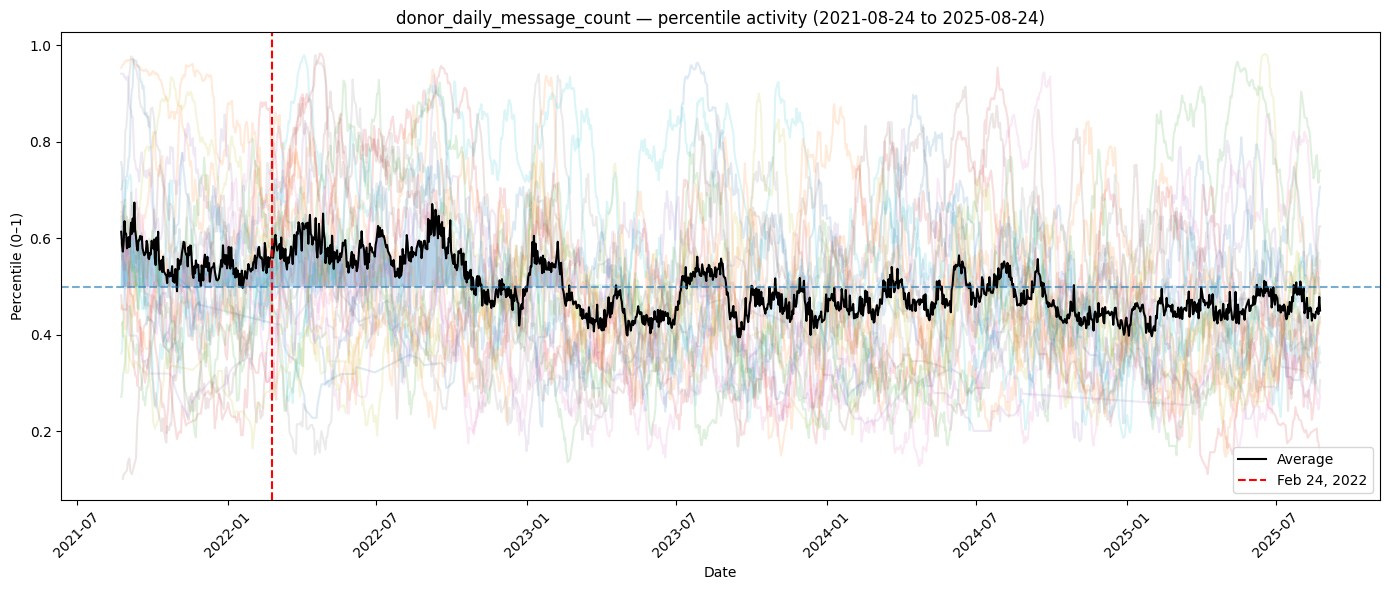

In [10]:
plt.figure(figsize=(14, 6))

for _, grp in df_plot.groupby("donation_id"):
    plt.plot(grp["date"], grp["quantile_ma"], alpha=0.15)

plt.plot(mean_series.index, mean_series, linewidth=1.5, color="black", label="Average")
plt.fill_between(
    mean_series.index, mean_series, threshold,
    where=(mean_series > threshold), interpolate=True, alpha=0.3)
plt.axhline(threshold, linestyle="--", alpha=0.6)
plt.axvline(war_date, color="red", linestyle="--", label="Feb 24, 2022")
plt.title(f"{metric} — percentile activity ({start_date} to {end_date})")
plt.ylabel("Percentile (0\u20131)")
plt.xlabel("Date")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Short term ±6 months

In [11]:
ma_window_2 = 7

In [12]:
event_window = 6
pre_limit = war_date - pd.DateOffset(months=event_window)
post_limit = war_date + pd.DateOffset(months=event_window)

In [13]:
data = df.pivot(index="date", columns="donation_id", values=metric).sort_index()
window_data = data.loc[pre_limit:post_limit]

all_ma = []
threshold = 0.5

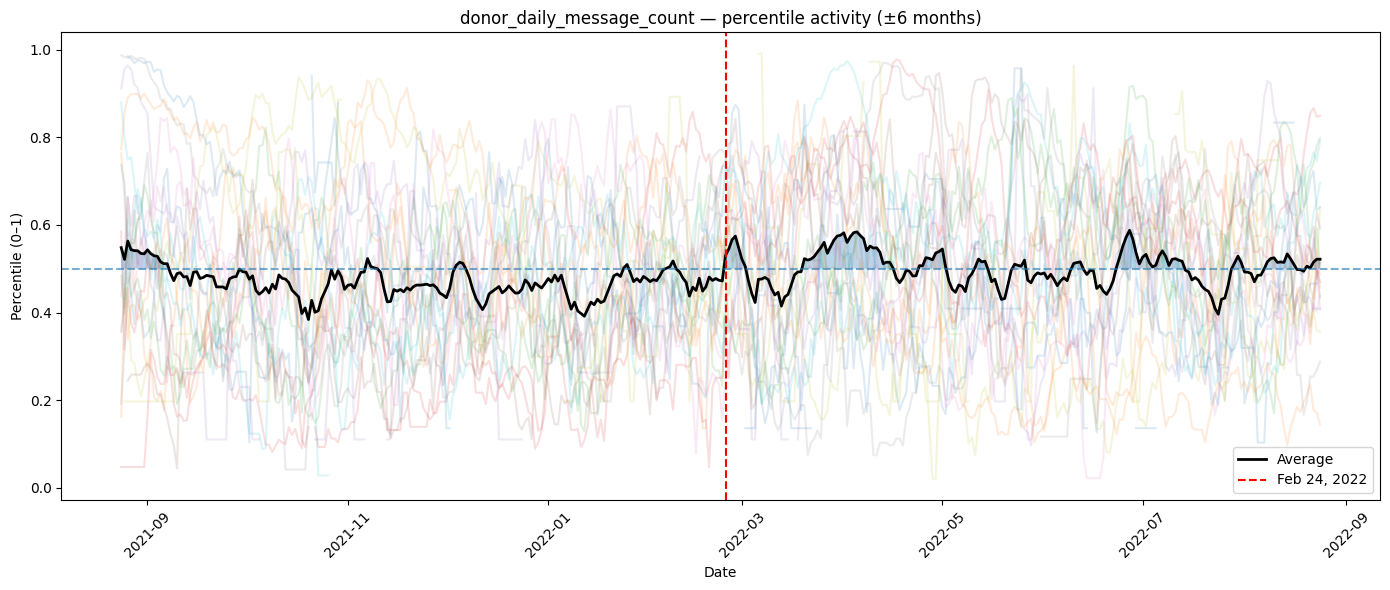

In [14]:
plt.figure(figsize=(14, 6))

for col in window_data.columns:
    series = window_data[col].astype(float)
    ma = series.rank(pct=True).rolling(ma_window_2, min_periods=1).mean()
    all_ma.append(ma)
    plt.plot(ma.index, ma, alpha=0.15)

mean_series = pd.concat(all_ma, axis=1).mean(axis=1)

plt.plot(mean_series.index, mean_series, linewidth=2, color="black", label="Average")
plt.fill_between(
    mean_series.index, mean_series, threshold,
    where=(mean_series > threshold), interpolate=True, alpha=0.3
)
plt.axhline(threshold, linestyle="--", alpha=0.6)
plt.axvline(war_date, color="red", linestyle="--", label="Feb 24, 2022")
plt.title(f"{metric} — percentile activity (\u00b1{event_window} months)")
plt.ylabel("Percentile (0\u20131)")
plt.xlabel("Date")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Wilcoxon signed-rank test 

In [15]:
exclude_donors = [
    "06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f",
    "179bbc95-ec8b-4a65-98c5-5d3b566806fa",
]

In [16]:
war_date = pd.to_datetime('2022-02-24')
window = 6
pre_limit  = war_date - pd.DateOffset(months=window)
post_limit = war_date + pd.DateOffset(months=window)

In [17]:
test_metrics = {
    "Messages sent by donor": ("donor_daily_message_count", base / "donor_daily_message_count.csv"),
    "Active chats": ("daily_active_chats", base / "daily_active_chats.csv"),
    "Active hours": ("donor_daily_active_hours", base / "donor_daily_active_hours.csv"),
    "Word count sent by donor": ("donor_daily_word_count", base / "donor_daily_word_count.csv"),
    "Reactions": ("donor_daily_reaction_count", base / "donor_daily_reactions.csv"),
    "Comments": ("donor_daily_comment_count", base / "donor_daily_comments.csv")
}

In [18]:
print(f"{'Metric':<28} {'N':>4} {'Before':>10} {'After':>10} {'W':>8} {'p-value':>10} {'Effect r':>10} {'Sig':>5}")
print('-' * 95)

results = []

for label, (col, fpath) in test_metrics.items():
    df_m = pd.read_csv(fpath)
    df_m['date'] = pd.to_datetime(df_m['date'])
    df_m = df_m[~df_m['donation_id'].isin(exclude_donors)]
    df_m = df_m[(df_m['date'] >= pre_limit) & (df_m['date'] <= post_limit)]

    df_m['pct'] = df_m.groupby('donation_id')[col].rank(pct=True)

    before = df_m[df_m['date'] <  war_date].groupby('donation_id')['pct'].mean()
    after = df_m[df_m['date'] >= war_date].groupby('donation_id')['pct'].mean()

    common = before.index.intersection(after.index)
    before = before.loc[common]
    after = after.loc[common]
    n = len(common)

    if n < 6:
        print(f"{label:<20} {n:>4} — insufficient data")
        continue

    stat, p = wilcoxon(before.values, after.values)

    z = norm.ppf(p / 2)
    r = abs(z) / np.sqrt(n)

    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    direction = '↑' if after.mean() > before.mean() else '↓'

    print(f"{label:<28} {n:>4} {before.mean():>10.3f} {after.mean():>10.3f} {stat:>8.1f} {p:>10.4f} {r:>10.3f} {sig:>4} {direction}")

    results.append({'metric': label, 'n': n, 'before': before.mean(),
                    'after': after.mean(), 'W': stat, 'p': p, 'r': r})

Metric                          N     Before      After        W    p-value   Effect r   Sig
-----------------------------------------------------------------------------------------------
Messages sent by donor         22      0.486      0.513     99.0     0.3880      0.184      ↑
Active chats                   22      0.474      0.522     69.0     0.1060      0.345      ↑
Active hours                   22      0.498      0.506    105.0     0.5028      0.143      ↑
Word count sent by donor       22      0.490      0.515     93.0     0.2902      0.225      ↑
Reactions                      22      0.485      0.507    122.0     0.8987      0.027      ↑
Comments                       22      0.530      0.552     82.5     0.4009      0.179      ↑


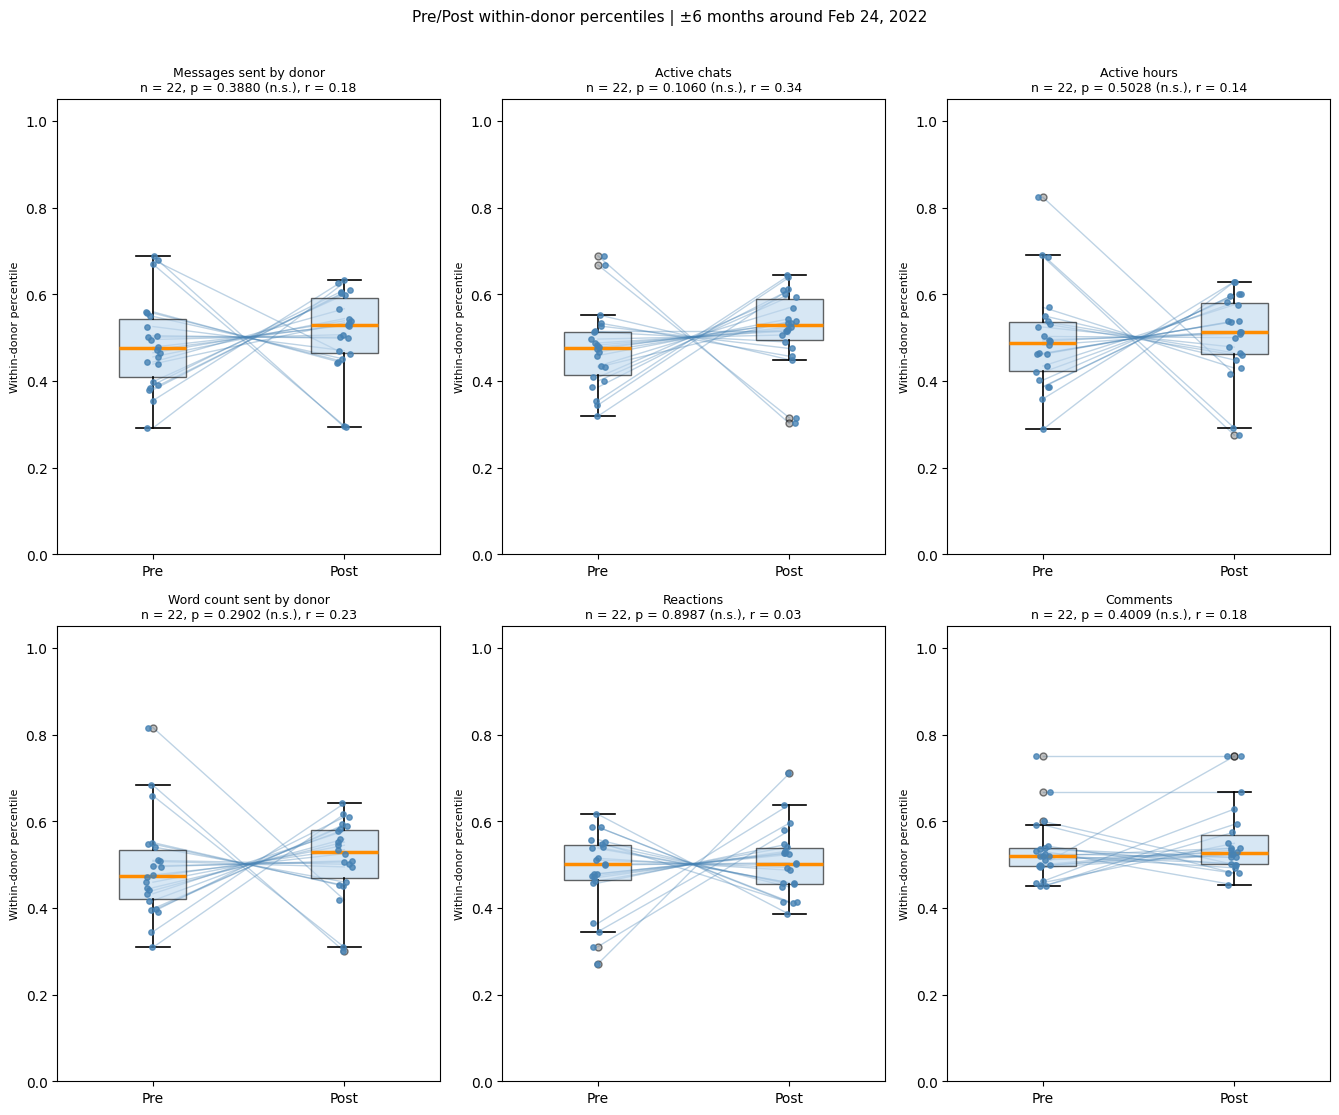

In [19]:
n_metrics = len(test_metrics)
ncols = 3
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 5.5))
axes = axes.flatten()

results = []

for i, (label, (col, fpath)) in enumerate(test_metrics.items()):
    ax = axes[i]

    df_m = pd.read_csv(fpath)
    df_m['date'] = pd.to_datetime(df_m['date'])
    df_m = df_m[~df_m['donation_id'].isin(exclude_donors)]
    df_m = df_m[(df_m['date'] >= pre_limit) & (df_m['date'] <= post_limit)]

    df_m['pct'] = df_m.groupby('donation_id')[col].rank(pct=True)

    before = df_m[df_m['date'] < war_date].groupby('donation_id')['pct'].mean()
    after = df_m[df_m['date'] >= war_date].groupby('donation_id')['pct'].mean()
    common = before.index.intersection(after.index)
    before, after = before.loc[common], after.loc[common]
    n = len(common)

    if n < 6:
        axes[i].set_visible(False)
        continue

    stat, p = wilcoxon(before.values, after.values)
    z = norm.ppf(p / 2)
    r = abs(z) / np.sqrt(n)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    results.append({'metric': label, 'n': n, 'before': before.mean(), 'after': after.mean(), 'p': p, 'r': r})

    bp = ax.boxplot(
        [before.values, after.values],
        positions=[0, 1], widths=0.35,
        patch_artist=True,
        boxprops=dict(facecolor='#BDD7EE', alpha=0.6),
        medianprops=dict(color='#FF8C00', linewidth=2.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=5, markerfacecolor='grey', alpha=0.5),
        zorder=2
    )

    for pre_val, post_val in zip(before.values, after.values):
        ax.plot([0, 1], [pre_val, post_val], color='steelblue', alpha=0.35, linewidth=1.0, zorder=1)

    jitter = np.random.uniform(-0.04, 0.04, size=n)
    ax.scatter(np.zeros(n) + jitter, before.values, color='steelblue', s=15, zorder=3, alpha=0.8)
    ax.scatter(np.ones(n) + jitter, after.values,  color='steelblue', s=15, zorder=3, alpha=0.8)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pre', 'Post'], fontsize=10)
    ax.set_ylabel('Within-donor percentile', fontsize=8)
    ax.set_title(label, fontsize=9, pad=6)
    ax.set_title(f"{label}\nn = {n}, p = {p:.4f} ({sig}), r = {r:.2f}", fontsize=9, pad=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Pre/Post within-donor percentiles | ±6 months around Feb 24, 2022', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()